# Do Audiences Tire of Nollywood's Screen Couples?
**Irene Undiandeye**

This notebook analyses the pairing premium of four recurring romantic couples in YouTube-era Nollywood: Maurice Sam and Sonia Uche, Maurice Sam and Uche Montana, Timini Egbuson and Bimbo Ademoye, and Uzor Arukwe and Bamike "BamBam" Olawunmi. The dataset is built by `src/build_dataset.py`. The **pairing premium** of a film is the difference, in log points, between its actual views and the views expected from the releasing channel, the film's age, its release year and the two actors' individual drawing power. A premium of +0.5 means about 65% more views than expected.

The questions are whether a couple's premium declines as they make more films together, where each couple's premium peaked, whether short gaps between films accelerate any decline, and whether audience engagement cools before reach does.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
d = pd.read_csv('../data/processed/couple_films_2026-10-06.csv', parse_dates=['published_at'])
d['log_k'] = np.log(d['k'])
d['log_gap'] = np.log1p(d['gap_days'])
d.groupby('couple').agg(films=('k', 'max'), first=('published_at', 'min'), last=('published_at', 'max'),
                        median_views=('view_count', 'median'), mean_premium=('premium', 'mean')).round(2)

,films,first,last,median_views,mean_premium
couple,,,,,
Maurice Sam & Sonia Uche,53,2022-10-04 16:30:11+00:00,2026-08-29 17:00:07+00:00,1905217.0,0.59
Maurice Sam & Uche Montana,16,2022-07-23 15:39:37+00:00,2026-08-20 14:26:45+00:00,6910723.0,0.44
Timini Egbuson & Bimbo Ademoye,12,2024-05-03 18:09:34+00:00,2026-05-05 17:15:02+00:00,1403157.5,-0.29
Uzor Arukwe & Bamike Olawunmi,6,2025-03-07 20:06:11+00:00,2026-07-16 17:15:29+00:00,6950555.5,0.91


## 1. Premium trajectories

Each point is one joint film, in release order; the line is a rolling median over three films, which is robust to the occasional film with unusually low views.

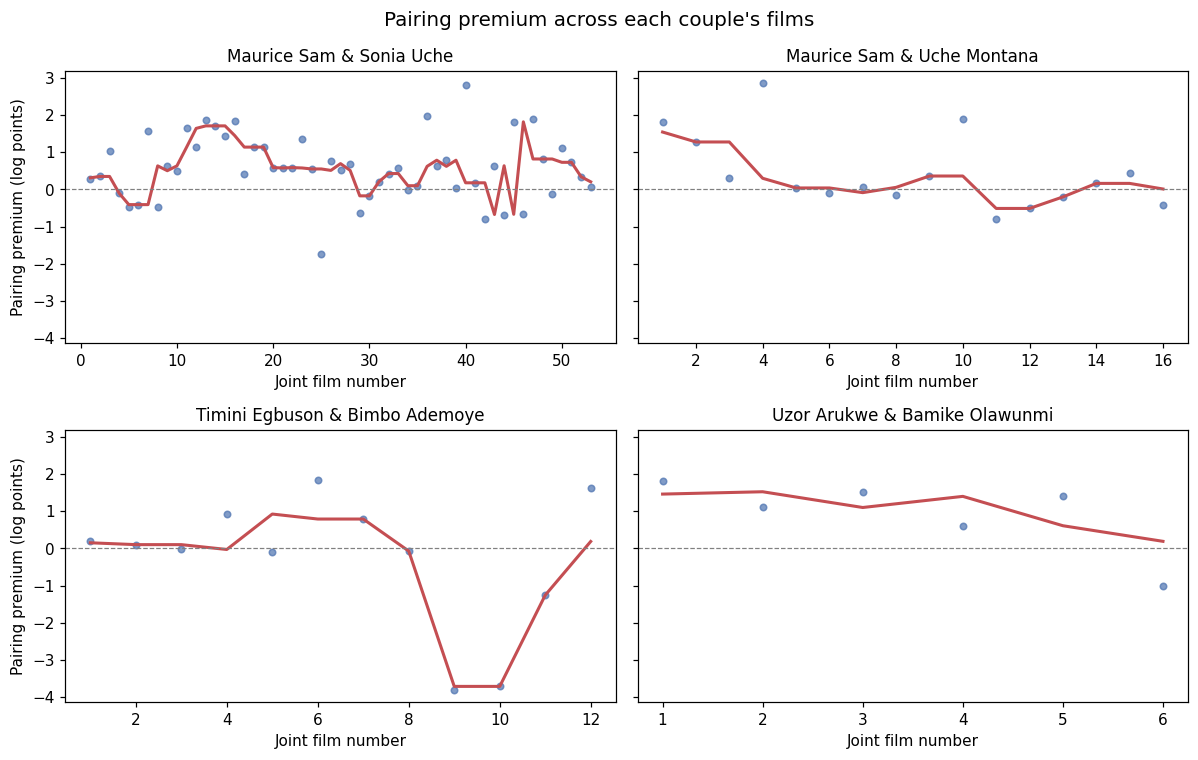

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
for ax, (couple, x) in zip(axes.flat, d.groupby('couple')):
    ax.scatter(x['k'], x['premium'], s=18, color='#4c72b0', alpha=0.7)
    ax.plot(x['k'], x['premium'].rolling(3, center=True, min_periods=2).median(), color='#c44e52', lw=2)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_title(couple, fontsize=11)
    ax.set_xlabel('Joint film number')
axes[0, 0].set_ylabel('Pairing premium (log points)')
axes[1, 0].set_ylabel('Pairing premium (log points)')
fig.suptitle('Pairing premium across each couple\'s films', fontsize=13)
plt.tight_layout()
plt.savefig('../images/premium_trajectories.png', bbox_inches='tight')
plt.show()

In [3]:
peaks = []
for couple, x in d.groupby('couple'):
    rm = x['premium'].rolling(3, center=True, min_periods=2).median().reset_index(drop=True)
    i = int(rm.idxmax())
    peaks.append({'couple': couple, 'peak_film': int(x['k'].iloc[i]), 'peak_title': x['title'].iloc[i][:45],
                  'peak_premium': round(rm.max(), 2), 'films': len(x)})
pd.DataFrame(peaks)

,couple,peak_film,peak_title,peak_premium,films
0,Maurice Sam & Sonia Uche,46,MR LECTURER MY LOVE (Full Movie) - MAURICE SA,1.82,53
1,Maurice Sam & Uche Montana,1,Maurice Sam and Uche Montana serving it hot i,1.55,16
2,Timini Egbuson & Bimbo Ademoye,5,"HEARTS ATTACHED - Timini Egbuson, Bimbo Ademo",0.93,12
3,Uzor Arukwe & Bamike Olawunmi,2,"TOO GOOD TO BE TRUE - UZOR ARUKWE, BAM BAM |",1.53,6


Three of the four couples peak within their first five films and then settle lower. Maurice Sam and Sonia Uche are the exception: their premium stays high across more than fifty films, with a late high point around film 46.

## 2. Does the premium decline with each new film?

A mixed-effects model pools all four couples, with a random intercept for each couple so that couples can differ in their overall appeal. The collaboration count enters in logs, so the model allows the novelty effect to fade fastest over a couple's first few films.

In [4]:
pooled = smf.mixedlm('premium ~ log_k', d, groups=d['couple']).fit(reml=True)
print(pooled.summary().tables[1])

            Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept   0.775    0.380   2.037  0.042   0.029  1.521
log_k      -0.183    0.134  -1.367  0.172  -0.445  0.079
Group Var   0.203    0.228                              


In [5]:
rows = []
for couple, x in d.groupby('couple'):
    m = smf.ols('premium ~ log_k', x).fit(cov_type='HC1')
    rows.append({'couple': couple, 'films': len(x), 'slope_per_log_film': round(m.params['log_k'], 3),
                 'p_value': round(m.pvalues['log_k'], 3)})
per_couple = pd.DataFrame(rows)
per_couple

,couple,films,slope_per_log_film,p_value
0,Maurice Sam & Sonia Uche,53,0.008,0.938
1,Maurice Sam & Uche Montana,16,-0.716,0.000
2,Timini Egbuson & Bimbo Ademoye,12,-0.672,0.270
3,Uzor Arukwe & Bamike Olawunmi,6,-1.028,0.072


Pooled across couples, the premium falls by about 0.18 log points for each roughly threefold increase in the collaboration count (one unit of its logarithm), but the estimate is imprecise (p ≈ 0.17), because the couples behave very differently. Separately, Maurice Sam and Uche Montana show a clear and statistically significant decline: their early films far outperformed expectations, while recent ones barely exceed them. Timini Egbuson and Bimbo Ademoye and Uzor Arukwe and BamBam show declines of similar size, but with only 12 and 6 films the estimates are too uncertain to confirm. Maurice Sam and Sonia Uche show no decline at all.

### Robustness: excluding extreme films

In [6]:
trimmed = d[d['premium'].abs() < 3]
robust = smf.mixedlm('premium ~ log_k', trimmed, groups=trimmed['couple']).fit(reml=True)
print(f"Films excluded: {len(d) - len(trimmed)}")
print(robust.summary().tables[1])

Films excluded: 2
            Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept   0.752    0.268   2.806  0.005   0.227  1.278
log_k      -0.076    0.119  -0.634  0.526  -0.310  0.158
Group Var   0.000    0.054                              


Excluding the two films with implausibly low views (around 7,000 to 9,000 views, likely restricted or re-uploaded versions) weakens the pooled decline further, confirming that there is no strong industry-wide fatigue effect in these couples; the decline is specific to some pairings.

## 3. Does over-exposure accelerate decline?

In [7]:
g = d.dropna(subset=['log_gap'])
gap_model = smf.mixedlm('premium ~ log_k + log_gap', g, groups=g['couple']).fit(reml=True)
print(gap_model.summary().tables[1])

            Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept   0.257    0.635   0.405  0.686  -0.988  1.502
log_k      -0.120    0.169  -0.709  0.478  -0.450  0.211
log_gap     0.095    0.102   0.933  0.351  -0.105  0.295
Group Var   0.214    0.239                              


The gap between a couple's films has a positive but insignificant coefficient: films released after longer breaks tend to do slightly better, but the evidence is weak. Over-exposure is not a clear driver of decline in this sample.

## 4. Does enthusiasm cool before reach?

Engagement is measured as likes per view. If audiences grow less enthusiastic about a couple before they stop watching, the like rate should fall with the collaboration count even where views hold up.

            Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept  -4.538    0.167  -27.218  0.000  -4.864  -4.211
log_k      -0.176    0.057   -3.068  0.002  -0.289  -0.064
Group Var   0.050    0.127                                


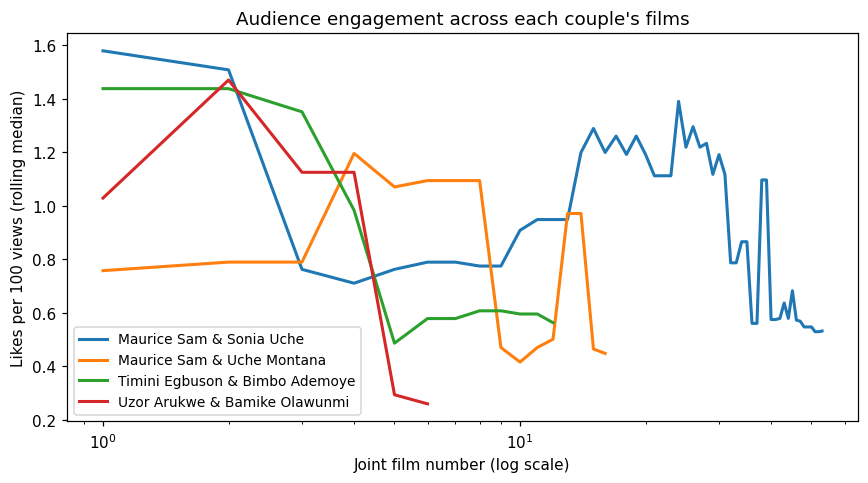

In [8]:
e = d[d['like_rate'] > 0].copy()
e['log_like_rate'] = np.log(e['like_rate'])
eng = smf.mixedlm('log_like_rate ~ log_k', e, groups=e['couple']).fit(reml=True)
print(eng.summary().tables[1])

fig, ax = plt.subplots(figsize=(8, 4.5))
for couple, x in e.groupby('couple'):
    ax.plot(x['k'], (x['like_rate'] * 100).rolling(3, center=True, min_periods=2).median(), lw=2, label=couple)
ax.set_xscale('log')
ax.set_xlabel('Joint film number (log scale)')
ax.set_ylabel('Likes per 100 views (rolling median)')
ax.set_title('Audience engagement across each couple\'s films')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../images/engagement_trend.png', bbox_inches='tight')
plt.show()

Engagement falls clearly and significantly as couples make more films together (p ≈ 0.002): each new film draws fewer likes per view, including for Maurice Sam and Sonia Uche, whose view premium holds steady. Enthusiasm cools even where reach does not, which makes the like rate a plausible early-warning signal of fatigue.

## 5. Conclusions

Across four of Nollywood's most prominent YouTube-era couples, there is no single fatigue curve. Maurice Sam and Uche Montana's pairing premium declined significantly after a very strong start, while Maurice Sam and Sonia Uche have sustained a premium of roughly 80% above expectations across more than fifty films. The two newer couples peaked early, but they have too few films to establish a trend. Release gaps show no clear effect. The most consistent finding is that audience engagement, measured as likes per view, declines steadily across a couple's collaborations, suggesting that enthusiasm fades before viewership does.

These results come with important limitations. Views are a single snapshot, so the film-age control approximates rather than measures each film's launch performance. Billing is inferred from titles and descriptions, and some re-uploads may remain despite deduplication. Four couples is a small sample, so the findings describe these pairings rather than Nollywood as a whole. Natural extensions are repeated snapshots to track each film's views over time, comment sentiment as a further engagement signal, and more couples once their filmographies grow.